# DQN Evaluation and Training Trajectory
This notebook loads saved DQN checkpoints, extracts training statistics, plots learning curves (reward, loss, moving averages), and provides a quick evaluation runner.

In [2]:
# Imports
import os
import json
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

sns.set(style="darkgrid")
plt.rcParams['figure.figsize'] = (10,5)

In [3]:
# Paths and helpers
ROOT = Path('.')
CKPT_DIR = ROOT / 'checkpoints'
def list_checkpoints(dirpath=CKPT_DIR):
    return [p for p in sorted(Path(dirpath).glob('*.pt'))]

list_checkpoints()

[WindowsPath('checkpoints/dqn.best.pt'), WindowsPath('checkpoints/dqn.pt')]

In [4]:
# Load checkpoint and extract saved stats (if present)
def load_checkpoint_stats(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Checkpoint not found: {path}')
    data = torch.load(path, map_location='cpu')
    extra = data.get('extra', {}) or {}
    stats = extra.get('stats', {}) if isinstance(extra, dict) else {}
    # Some checkpoints may store stats directly in 'extra' or under other keys
    if not stats and isinstance(data.get('extra'), dict):
        stats = data['extra'].get('stats', {}) or {}
    return {
        'path': str(path),
        'train_steps': int(data.get('train_steps', 0)),
        'episodes': int(data.get('episodes', 0)),
        'stats': stats,
        'raw': data,
    }

# Quick smoke-test load (if file exists)
for p in list_checkpoints():
    print(p)

checkpoints\dqn.best.pt
checkpoints\dqn.pt


In [5]:
# Plotting utilities for training stats
def plot_training_stats(stats: dict, window=10, show=True):
    # stats expected as dict containing 'episode_rewards' and optional 'episode_losses'
    rewards = stats.get('episode_rewards', []) or []
    losses = stats.get('episode_losses', []) or []
    df = pd.DataFrame({'reward': rewards, 'loss': losses})
    df['reward_ma'] = df['reward'].rolling(window, min_periods=1).mean()
    fig, axes = plt.subplots(1,2, figsize=(14,5))
    axes[0].plot(df['reward'], alpha=0.4, label='reward')
    axes[0].plot(df['reward_ma'], color='C1', label=f'{window}-ep MA')
    axes[0].set_title('Episode Reward')
    axes[0].set_xlabel('Episode')
    axes[0].legend()
    if df['loss'].notnull().any():
        axes[1].plot(df['loss'], alpha=0.6, label='loss')
        axes[1].set_title('Episode Loss (avg per episode)')
        axes[1].set_xlabel('Episode')
    else:
        axes[1].text(0.5,0.5,'No loss data found', ha='center', va='center')
        axes[1].set_axis_off()
    plt.tight_layout()
    if show:
        plt.show()
    return df

Loaded checkpoints\dqn.pt train_steps= 767001 episodes= 384


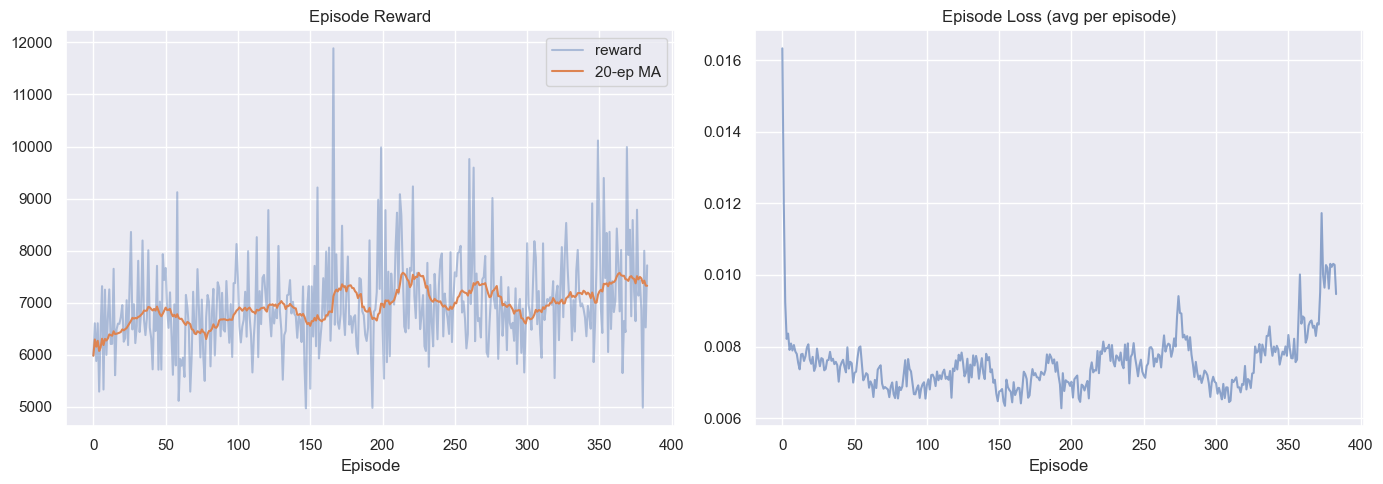

In [6]:
# Load default checkpoint (checkpoints/dqn.pt) and plot if stats exist
default_ckpt = CKPT_DIR / 'dqn.pt'
if default_ckpt.exists():
    info = load_checkpoint_stats(default_ckpt)
    print('Loaded', info['path'], 'train_steps=', info['train_steps'], 'episodes=', info['episodes'])
    stats = info['stats'] or {}
    if stats:
        df = plot_training_stats(stats, window=20)
    else:
        print('No training stats found inside checkpoint extra metadata.')
else:
    print('Default checkpoint not found at', default_ckpt)

Loaded best checkpoints\dqn.best.pt train_steps= 99001 episodes= 50


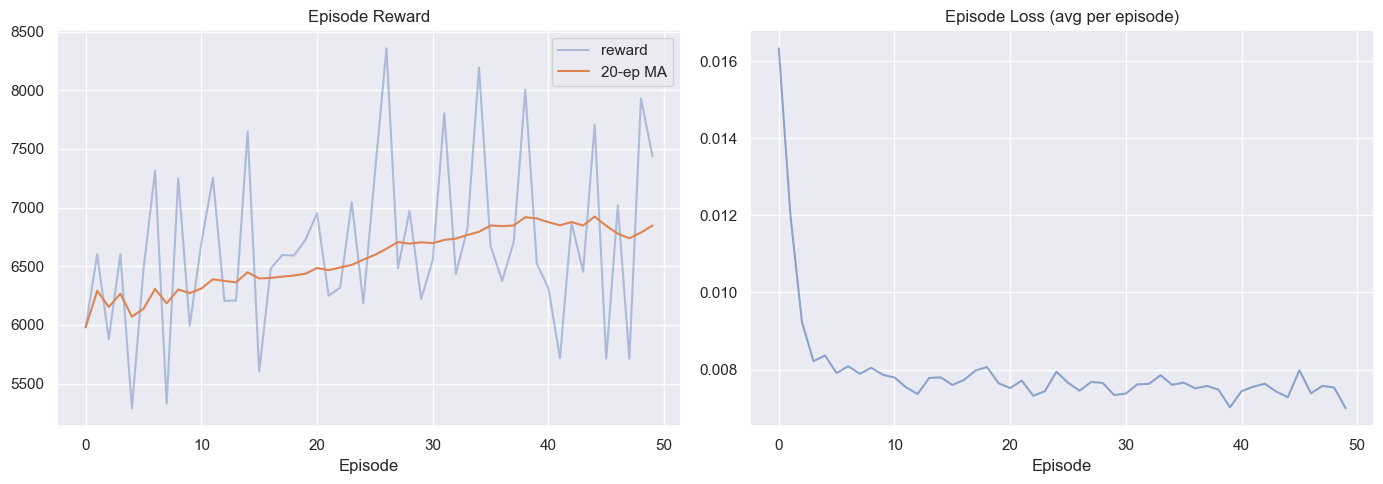

In [7]:
# Load best checkpoint (checkpoints/dqn.best.pt) and plot if present
best_ckpt = CKPT_DIR / 'dqn.best.pt'
if best_ckpt.exists():
    info_best = load_checkpoint_stats(best_ckpt)
    print('Loaded best', info_best['path'], 'train_steps=', info_best['train_steps'], 'episodes=', info_best['episodes'])
    stats_best = info_best['stats'] or {}
    if stats_best:
        df_best = plot_training_stats(stats_best, window=20)
else:
    print('No best checkpoint found at', best_ckpt)

Running evaluation with checkpoint: checkpoints\dqn.pt
Eval episode rewards: [6240.0, 6531.0, 7825.0, 7109.0, 6038.0]


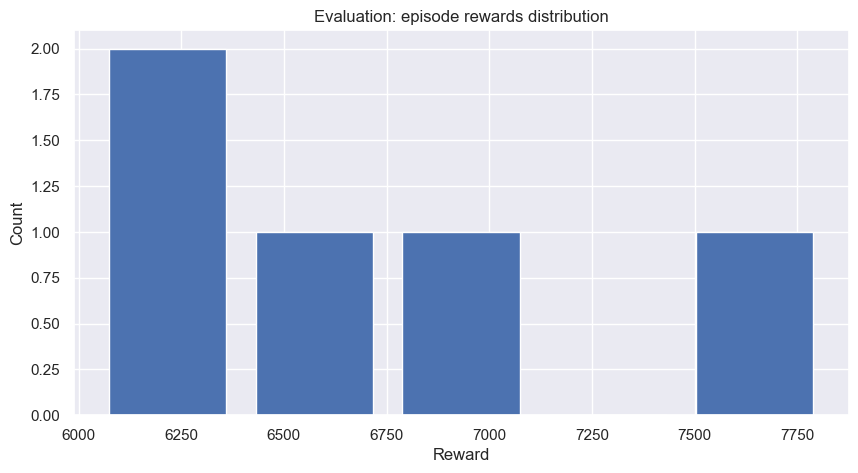

In [8]:
# Quick evaluation runner: uses run_evaluation flow from dqn.py
from dqn import DQNConfig, run_evaluation

# Configure evaluation - set `checkpoint_path` to the checkpoint you want to evaluate
cfg = DQNConfig()
cfg.checkpoint_path = str(default_ckpt) if default_ckpt.exists() else str(best_ckpt)
cfg.eval_episodes = 5

print('Running evaluation with checkpoint:', cfg.checkpoint_path)
try:
    results = run_evaluation(cfg)
    print('Eval episode rewards:', results.get('episode_rewards'))
    import matplotlib.pyplot as plt
    plt.hist(results.get('episode_rewards', []), bins=max(1,len(results.get('episode_rewards', []))), rwidth=0.8)
    plt.title('Evaluation: episode rewards distribution')
    plt.xlabel('Reward')
    plt.ylabel('Count')
    plt.show()
except Exception as exc:
    print('Evaluation failed:', exc)
    print('You may need the full Tribes environment and required Java/paths available to run evaluation.')

## Next steps
- If training stats are missing from checkpoints, rerun training with `extra={'stats': stats}` saved (this repo already saves `stats` into checkpoint extras).
- Increase `cfg.eval_episodes` for more stable evaluation estimates.
- If you want time-series of other metrics (epsilon, global step), extract them from `extra` when available.